In [1]:
import numpy as np
from datasets import load_dataset
import sys
sys.path.append("../")
from cumulant_analyzer import CumulantAnalyzer, to_numpy
from transformers.utils.logging import disable_progress_bar
disable_progress_bar()
from plot_utils import plot_comparison_transposed_with_std
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
analyzer = CumulantAnalyzer(model_name='gpt2-large', max_length = 256, verbose = False)

In [3]:
def get_indices(input_topic):
    filered_topics = [item['pile_set_name'] for i, item in enumerate(ds['meta']) if i in filtered_indices]
    indices = [i for i, topic in enumerate(filered_topics) if topic == input_topic]
    return indices
    
def choose_random_index_from_topic(input_topic):
    indices = get_indices(input_topic)
    return np.random.choice(indices)

In [4]:
ds = load_dataset("NeelNanda/pile-10k")['train']
filtered_indices = np.load('filtered_indices.npy')

In [5]:
topic1 = "DM Mathematics"
indices = get_indices(topic1)
all_stats1 = [analyzer.compute_stats(ds['text'][filtered_indices[index]]) for index in tqdm(indices)]

topic2 = "Pile-CC"
indices = get_indices(topic2)
all_stats2 = [analyzer.compute_stats(ds['text'][filtered_indices[index]]) for index in tqdm(indices)]


  0%|          | 0/99 [00:00<?, ?it/s]

  0%|          | 0/570 [00:00<?, ?it/s]

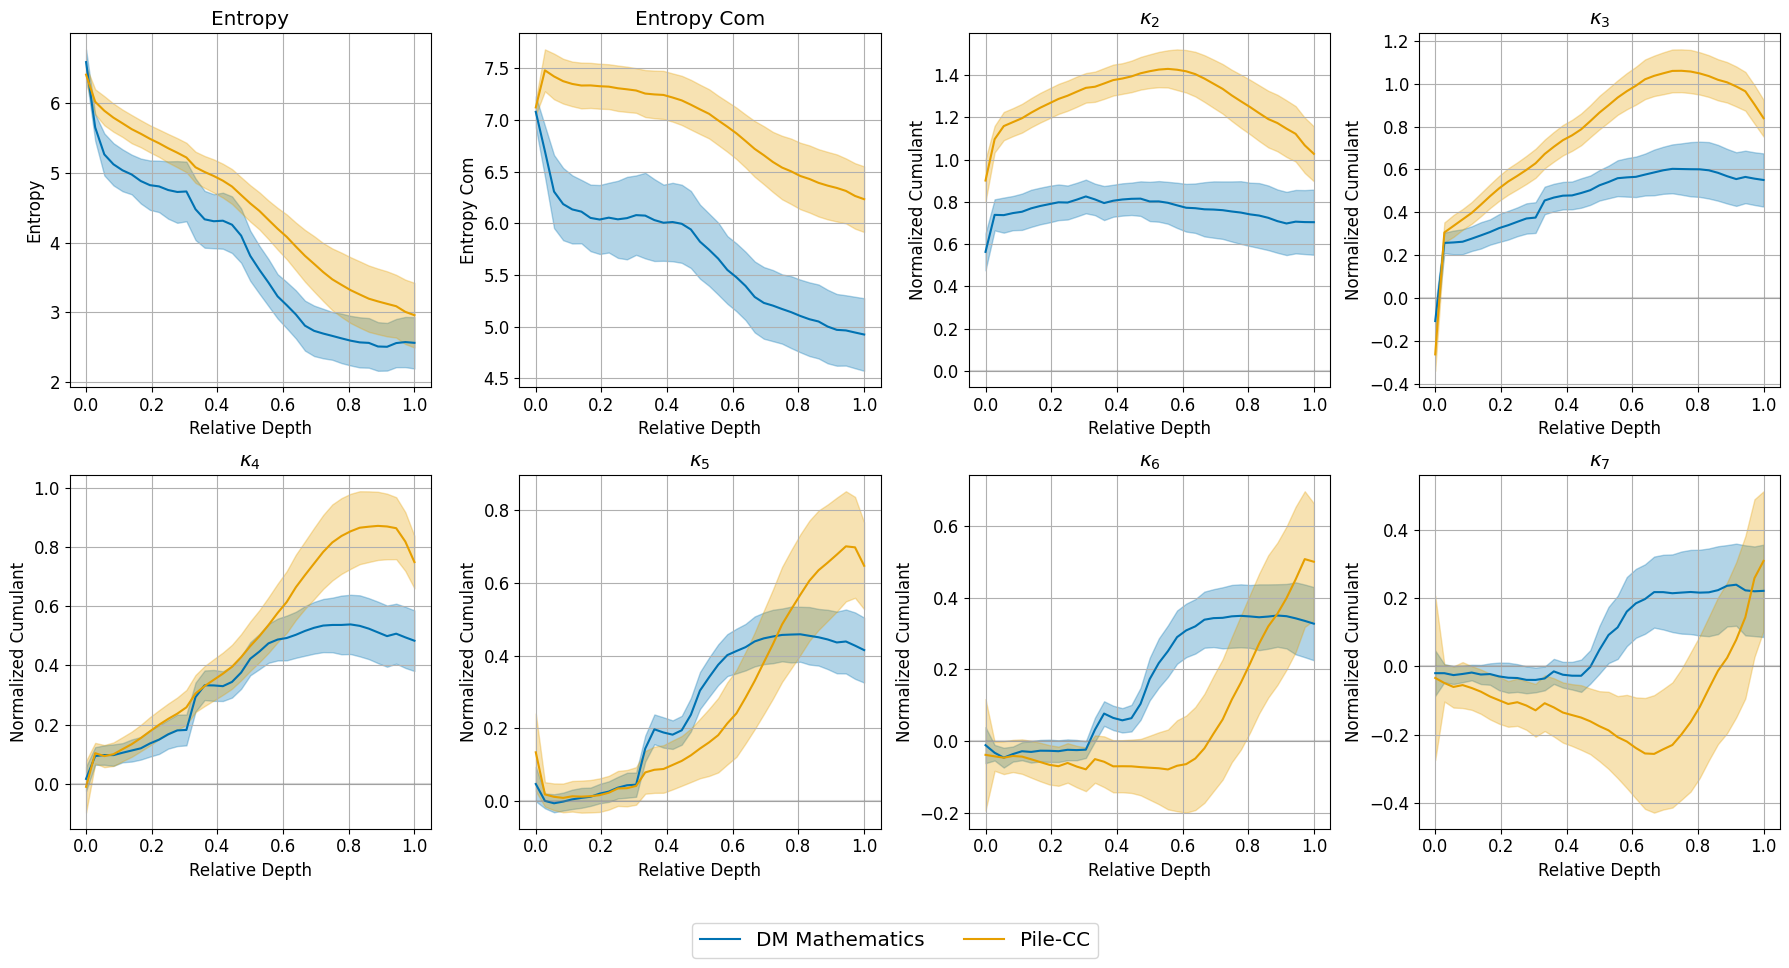

In [6]:
def average_stats(all_stats):
   keys = all_stats[0].keys()
   return {k: np.mean([s[k] for s in all_stats], axis=0) for k in keys}

def compute_stats_with_std(all_stats):
    keys = all_stats[0].keys()
    stats_with_std = {}
    
    for key in keys:
        values = np.array([s[key] for s in all_stats])
        stats_with_std[f'{key}_mean'] = np.mean(values, axis=0)
        stats_with_std[f'{key}_std'] = np.std(values, axis=0)
    
    return stats_with_std

# Compute statistics with std
stats1_with_std = compute_stats_with_std(all_stats1)
stats2_with_std = compute_stats_with_std(all_stats2)

# Create the enhanced plot
fig = plot_comparison_transposed_with_std(stats1_with_std, stats2_with_std, [topic1, topic2], figsize=(18, 9))
fig.savefig('plots/cumulant_comparison_topics_with_std.png', bbox_inches='tight')
plt.show()